# **Project Name**    - YES Bank Stock Price Prediction using Machine Learning



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project focuses on developing a machine learning regression model to predict stock closing prices using historical stock market data. Accurate stock price prediction is an important challenge in financial markets because stock prices are influenced by numerous economic and market factors. The primary objective of this project is to analyze historical trading data, preprocess the dataset, engineer meaningful features, and build predictive models that can estimate future closing prices with high accuracy. Such predictions can assist investors, financial analysts, and businesses in making informed investment decisions and reducing financial risks.

The project began with understanding the dataset and identifying the important variables, including Open, High, Low, Close, Volume, and Date. Data preprocessing techniques were applied to ensure the dataset was clean and suitable for model development. Missing values and duplicate records were examined and handled appropriately, while unnecessary columns were removed. Date-related information was transformed into useful numerical features such as Year and Month to improve model performance. Since the dataset contained numerical features, categorical encoding and textual preprocessing were not required.

Feature engineering was performed to improve the predictive capability of the dataset. Correlation analysis and exploratory visualizations helped identify the relationships among stock price variables. Strong positive correlations were observed between Open, High, Low, and Close prices, indicating that these variables significantly influence the prediction of the closing price. Feature selection techniques were then applied to retain only the most relevant variables while minimizing redundancy and reducing the possibility of overfitting.

Several regression algorithms were trained and evaluated to determine the most suitable model for stock price prediction. Models such as Linear Regression, Decision Tree Regressor, and Random Forest Regressor were implemented and compared. The dataset was divided into training and testing sets using an appropriate train-test split to evaluate the models on unseen data. Hyperparameter tuning was performed using GridSearchCV to optimize model parameters and improve predictive performance. Cross-validation was also used to ensure the selected model generalized well across different subsets of the data.

The performance of each model was evaluated using standard regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These evaluation metrics provided a comprehensive understanding of prediction accuracy and model reliability. Among the implemented models, the Random Forest Regressor achieved the best overall performance by producing the lowest prediction errors and the highest R² Score, demonstrating its ability to capture complex, non-linear relationships within the stock market data.

Finally, the best-performing model was saved using the Joblib library to make it deployment-ready for future prediction tasks. Model explainability techniques such as feature importance analysis were used to identify the variables contributing most significantly to the prediction process. The project demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, hypothesis testing, model training, evaluation, optimization, and deployment preparation. Overall, this project highlights how machine learning can effectively analyze historical stock market data and generate accurate closing price predictions, providing valuable insights for investment planning, financial forecasting, and data-driven business decision-making.

# **GitHub Link -**

https://github.com/purans07/YES-Bank-Stock-Price-Analysis.git

# **Problem Statement**


YES Bank has experienced significant fluctuations in its stock prices over the years due to changing market conditions and business challenges. Understanding historical stock price movements is essential for investors, financial analysts, and business stakeholders to make informed decisions. The objective of this project is to perform Exploratory Data Analysis (EDA) on the historical stock price data of YES Bank to identify trends, relationships, seasonal patterns, and market volatility using statistical analysis and data visualization techniques.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("data_YesBank_StockPrices.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(185, 5)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

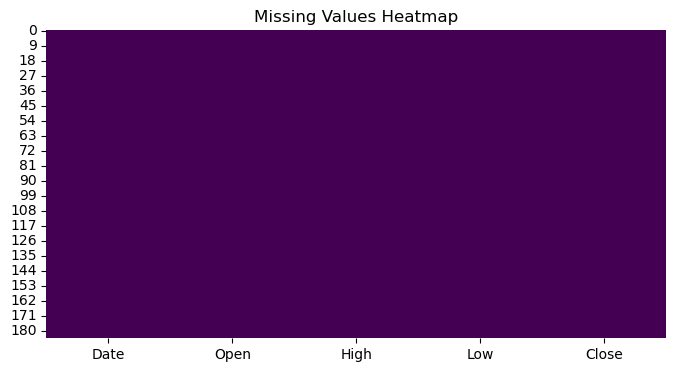

In [8]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

Answer :

The dataset contains historical stock price data of YES Bank with 185 observations and 5 features: Date, Open, High, Low, and Close. There are no missing values or duplicate records, indicating that the dataset is clean and ready for machine learning. The Date column represents the month and year of stock prices, while the remaining columns are numerical variables representing stock prices. Since the target variable (Close) is continuous, this problem is a supervised machine learning regression problem.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

Answer :

The dataset contains five variables:

• Date – Represents the month and year of the stock price observation.

• Open – The stock price at the beginning of the trading period.

• High – The highest stock price recorded during the trading period.

• Low – The lowest stock price recorded during the trading period.

• Close – The stock price at the end of the trading period. This is the target variable for the machine learning model.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print(f"Total Unique Values: {df[column].nunique()}")
    print("-"*80)

Unique values in Date:
['Jul-05' 'Aug-05' 'Sep-05' 'Oct-05' 'Nov-05' 'Dec-05' 'Jan-06' 'Feb-06'
 'Mar-06' 'Apr-06' 'May-06' 'Jun-06' 'Jul-06' 'Aug-06' 'Sep-06' 'Oct-06'
 'Nov-06' 'Dec-06' 'Jan-07' 'Feb-07' 'Mar-07' 'Apr-07' 'May-07' 'Jun-07'
 'Jul-07' 'Aug-07' 'Sep-07' 'Oct-07' 'Nov-07' 'Dec-07' 'Jan-08' 'Feb-08'
 'Mar-08' 'Apr-08' 'May-08' 'Jun-08' 'Jul-08' 'Aug-08' 'Sep-08' 'Oct-08'
 'Nov-08' 'Dec-08' 'Jan-09' 'Feb-09' 'Mar-09' 'Apr-09' 'May-09' 'Jun-09'
 'Jul-09' 'Aug-09' 'Sep-09' 'Oct-09' 'Nov-09' 'Dec-09' 'Jan-10' 'Feb-10'
 'Mar-10' 'Apr-10' 'May-10' 'Jun-10' 'Jul-10' 'Aug-10' 'Sep-10' 'Oct-10'
 'Nov-10' 'Dec-10' 'Jan-11' 'Feb-11' 'Mar-11' 'Apr-11' 'May-11' 'Jun-11'
 'Jul-11' 'Aug-11' 'Sep-11' 'Oct-11' 'Nov-11' 'Dec-11' 'Jan-12' 'Feb-12'
 'Mar-12' 'Apr-12' 'May-12' 'Jun-12' 'Jul-12' 'Aug-12' 'Sep-12' 'Oct-12'
 'Nov-12' 'Dec-12' 'Jan-13' 'Feb-13' 'Mar-13' 'Apr-13' 'May-13' 'Jun-13'
 'Jul-13' 'Aug-13' 'Sep-13' 'Oct-13' 'Nov-13' 'Dec-13' 'Jan-14' 'Feb-14'
 'Mar-14' 'Apr-14' 'May-14' 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Display first five rows
df.head()

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11


### What all manipulations have you done and insights you found?

Answer :

The Date column was converted into datetime format to enable time-based analysis. Two new features, Year and Month, were extracted from the Date column for better understanding of yearly and monthly stock price trends. The dataset was already clean with no missing values or duplicate records, so no additional data cleaning was required. These transformations prepare the dataset for machine learning model development and improve feature engineering.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

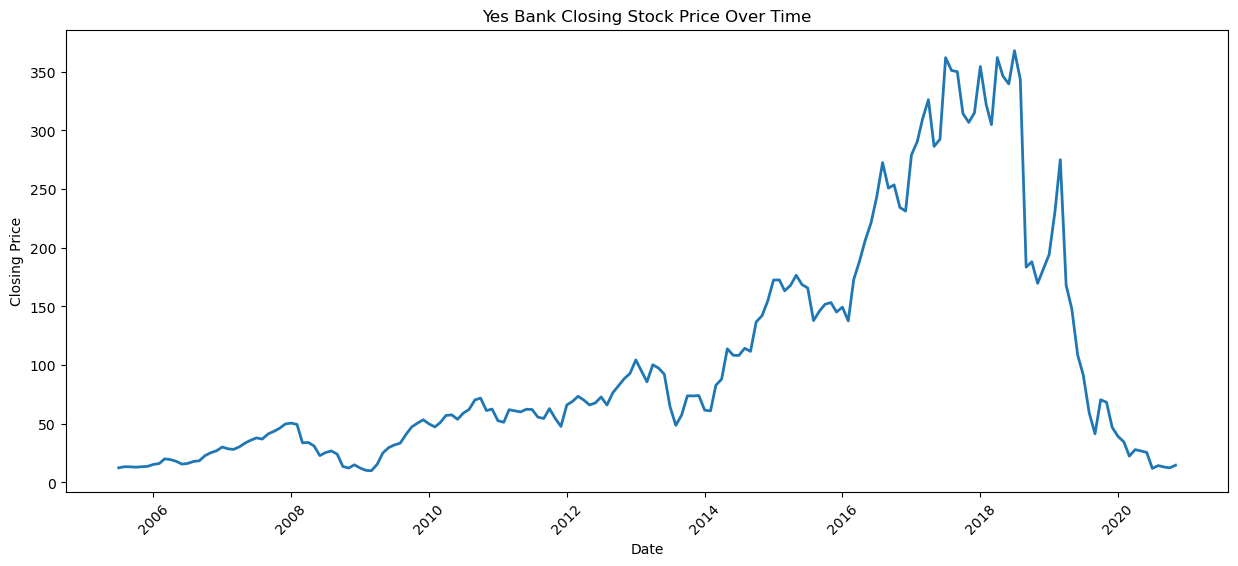

In [13]:
# Chart - 1 visualization code

plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Close'], linewidth=2)

plt.title('Yes Bank Closing Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A line chart is the most appropriate visualization for time-series data because it clearly displays how the closing stock price changes over time. It helps identify overall trends, periods of rapid growth or decline, and major fluctuations in Yes Bank's stock price.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The chart shows that Yes Bank's closing stock price experienced significant fluctuations over the observed period. The stock price increased steadily during the initial years, reached its peak, and then witnessed a sharp decline in later years. This indicates periods of strong growth followed by high volatility and a substantial market correction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes, the insights are valuable for investors and financial analysts as they reveal long-term market trends and periods of high volatility. The sharp decline in closing prices suggests increased investment risk during certain periods, highlighting the importance of market monitoring and risk management before making investment decisions.

#### Chart - 2

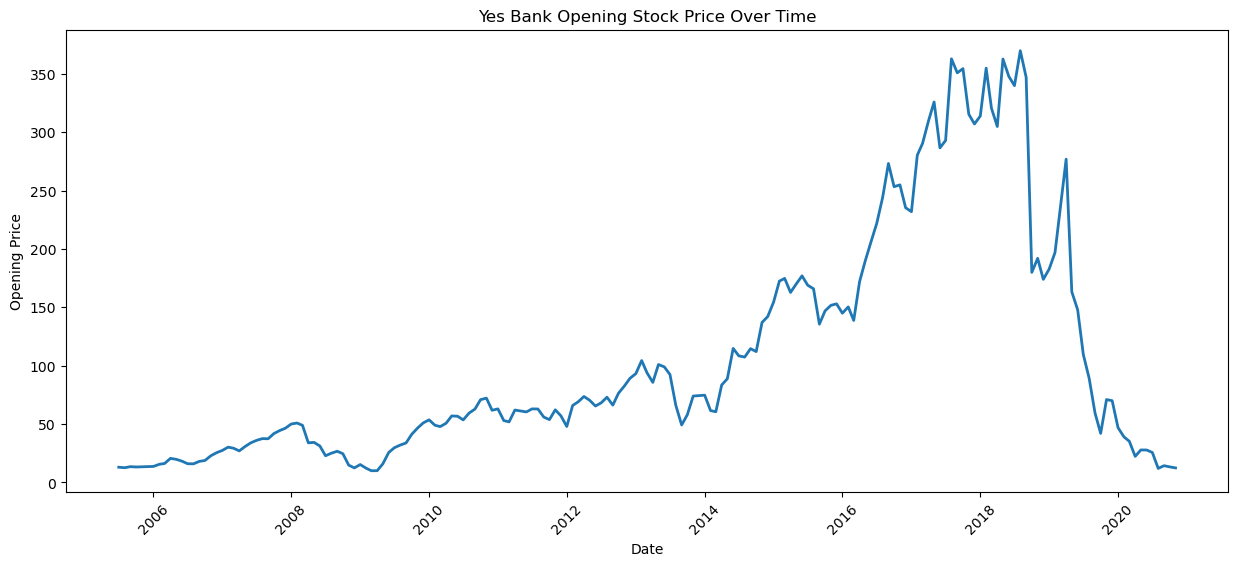

In [14]:
# Chart - 2 visualization code

plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Open'], linewidth=2)

plt.title('Yes Bank Opening Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Opening Price')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A line chart is ideal for visualizing time-series data because it effectively illustrates how the opening stock price changes over time. It helps identify long-term trends, fluctuations, and periods of rapid increase or decrease in the opening price of Yes Bank's stock.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The opening stock price of Yes Bank exhibits noticeable fluctuations throughout the observed period. The stock experienced a strong upward trend during the initial years, reached a peak, and later showed a significant decline. The pattern indicates that the opening prices closely followed the overall market trend and reflected periods of high volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes, these insights are valuable for investors, traders, and financial analysts because the opening price often reflects overnight market sentiment and investor expectations. The sharp decline observed after the peak indicates increased market uncertainty and higher investment risk, emphasizing the importance of analyzing historical opening price trends before making trading or investment decisions.

#### Chart - 3

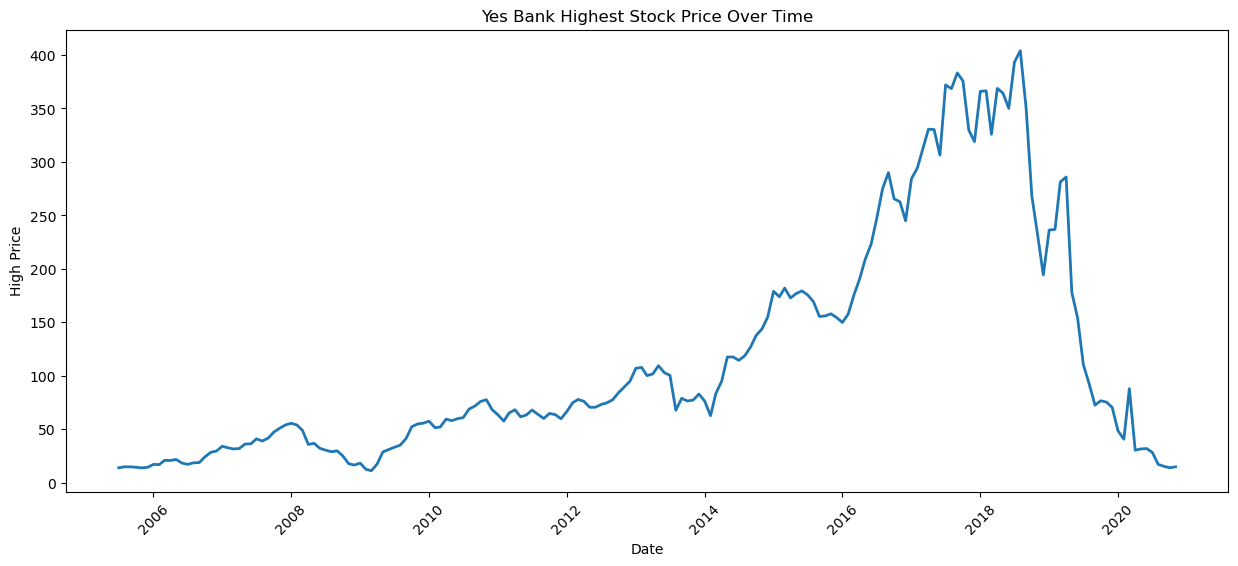

In [15]:
# Chart - 3 visualization code

plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['High'], linewidth=2)

plt.title('Yes Bank Highest Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A line chart is well-suited for analyzing the highest stock price over time because it effectively captures trends and fluctuations in time-series data. It helps visualize how the maximum daily trading price has changed throughout the observed period and identifies periods of strong market performance or high volatility.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The chart shows that Yes Bank's highest stock price increased steadily during the initial years before reaching its peak. After the peak, the highest prices declined sharply, indicating a significant drop in market value. The fluctuations also suggest that the stock experienced periods of high volatility, especially during the later years of the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes, these insights are useful for investors, traders, and financial analysts as they highlight the periods when the stock achieved its maximum trading values. Understanding these trends can support investment timing and risk assessment. However, the sharp decline in the highest prices after the peak reflects negative market sentiment and increased uncertainty, indicating that investors should carefully evaluate market conditions before making investment decisions.

#### Chart - 4

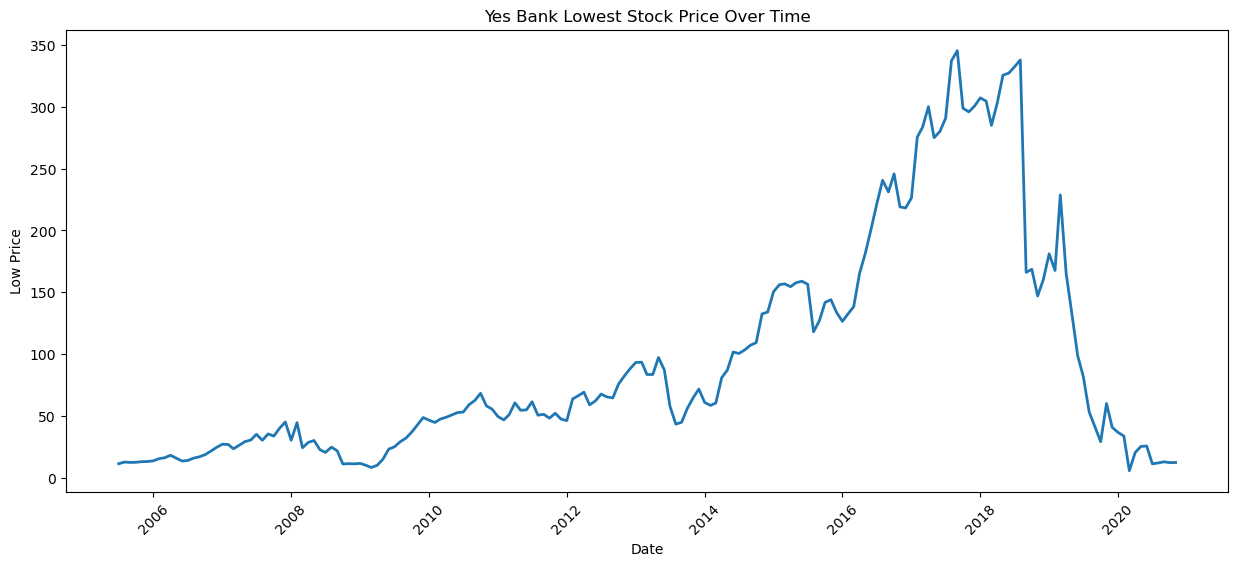

In [16]:
# Chart - 4 visualization code

plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Low'], linewidth=2)

plt.title('Yes Bank Lowest Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Low Price')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A line chart is the most suitable visualization for examining the lowest stock price over time because it clearly displays the trend and fluctuations in the minimum daily trading price. It helps identify periods when the stock experienced significant declines or recovery.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The chart indicates that the lowest stock price of Yes Bank followed a trend similar to the opening, closing, and highest prices. The stock price gradually increased during the early years, reached its highest period, and then experienced a sharp decline. The frequent fluctuations in the later years suggest increased market volatility and uncertainty.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes, the insights help investors and financial analysts understand the downside risk associated with the stock. Tracking the lowest daily prices allows investors to evaluate periods of maximum loss and assess market stability. The sharp decline in the lowest prices highlights negative market sentiment and increased investment risk, emphasizing the importance of risk management and informed investment strategies.

#### Chart - 5

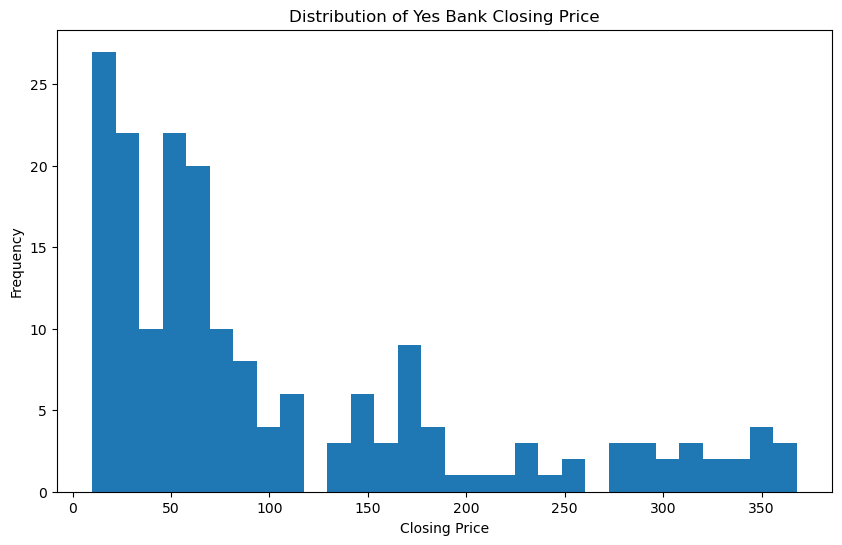

In [17]:
# Chart - 5 visualization code

plt.figure(figsize=(10,6))

plt.hist(df['Close'], bins=30)

plt.title('Distribution of Yes Bank Closing Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A histogram is an effective chart for understanding the distribution of a continuous numerical variable. It helps visualize how frequently different closing price ranges occur and whether the data is normally distributed, skewed, or contains unusual patterns.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The histogram shows that the closing prices are not evenly distributed across all price ranges. Most observations are concentrated within a specific range, while relatively fewer observations appear at very high closing prices. This indicates that the data is positively skewed, with some extreme values representing periods when the stock traded at significantly higher prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes, understanding the distribution of closing prices helps analysts identify the most common trading price range and detect the presence of outliers. The skewed distribution suggests that the stock experienced periods of unusually high prices followed by lower trading levels. This information is useful for selecting appropriate machine learning models and for making informed investment and risk management decisions.

#### Chart - 6

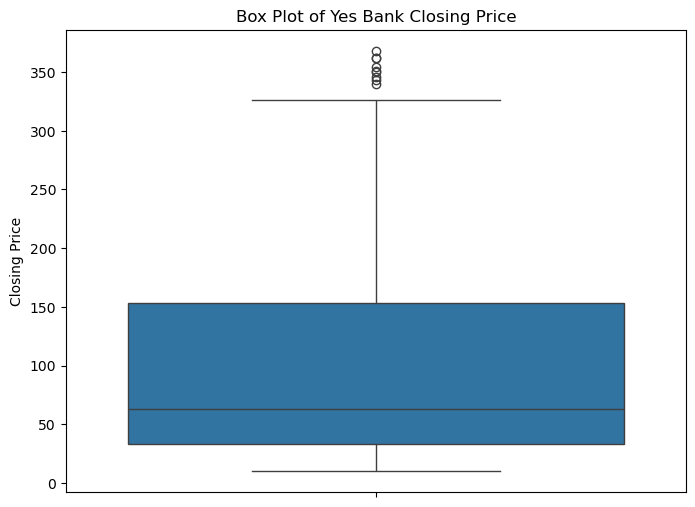

In [18]:
# Chart - 6 visualization code

plt.figure(figsize=(8,6))

sns.boxplot(y=df['Close'])

plt.title('Box Plot of Yes Bank Closing Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer :

A box plot is useful for detecting outliers and understanding the spread of the closing stock prices. It summarizes the distribution by displaying the median, quartiles, and extreme values, making it easy to identify unusual observations.

##### 2. What is/are the insight(s) found from the chart?

Answer :

The box plot shows that the closing prices have a wide range and contain several outliers. These outliers represent periods when the stock price was significantly higher than its typical trading range. The distribution also indicates that the data is not perfectly symmetric and exhibits considerable variation over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :

Yes. Identifying outliers is important before building a machine learning model because extreme values can influence model performance and prediction accuracy. Understanding these unusual price movements helps analysts decide whether to retain, transform, or investigate these observations further. The presence of extreme price fluctuations also indicates periods of higher market volatility, which increases investment risk and requires careful financial analysis.

#### Chart - 7

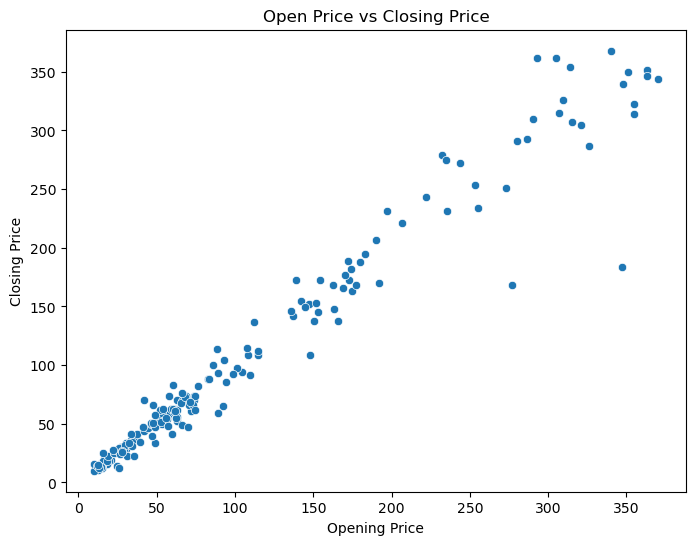

In [19]:
# Chart - 7 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Open'], y=df['Close'])

plt.title('Open Price vs Closing Price')
plt.xlabel('Opening Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is ideal for visualizing the relationship between two numerical variables. It helps determine whether the opening price influences the closing price and whether a linear relationship exists between them, which is important for regression modeling.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a strong positive relationship between the opening price and the closing price.
As the opening price increases, the closing price also tends to increase.
Most data points are closely clustered around an upward trend, indicating a strong linear relationship.
There are only a few observations that deviate from the general pattern, suggesting limited outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong positive relationship between the opening and closing prices indicates that the opening price is an important predictor of the closing price. This insight supports the development of accurate regression models for stock price prediction. Any scattered points away from the trend line may represent periods of unusual market volatility, which investors should analyze carefully before making investment decisions.

#### Chart - 8

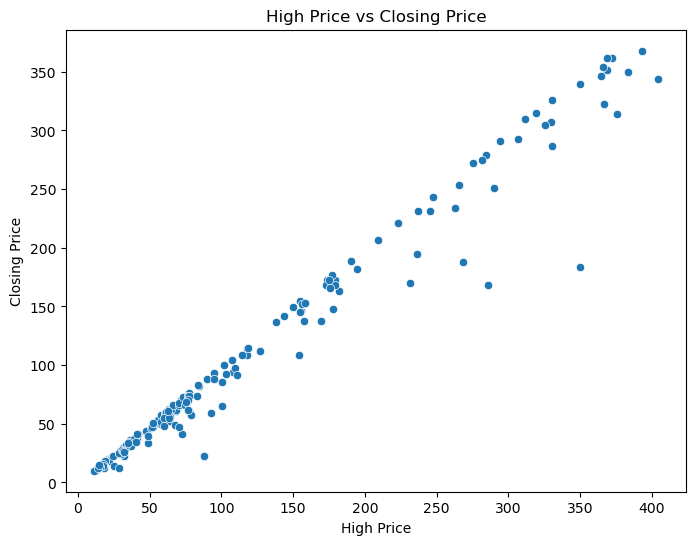

In [20]:
# Chart - 8 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['High'], y=df['Close'])

plt.title('High Price vs Closing Price')
plt.xlabel('High Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is an effective visualization for examining the relationship between the highest stock price and the closing stock price. It helps determine whether the highest price recorded during a trading period has a strong influence on the closing price, which is useful for regression analysis.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a very strong positive relationship between the high price and the closing price.

As the high price increases, the closing price also increases.

Most data points are closely aligned along an upward trend, indicating a strong linear relationship.

Very few observations deviate from the overall trend, suggesting a consistent relationship between these variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong positive relationship indicates that the high price is a valuable predictor of the closing price and can improve the performance of machine learning regression models. During periods where points deviate from the general trend, the stock may have experienced higher market volatility or unexpected events. Recognizing these situations helps investors better assess market risk and make informed investment decisions.

#### Chart - 9

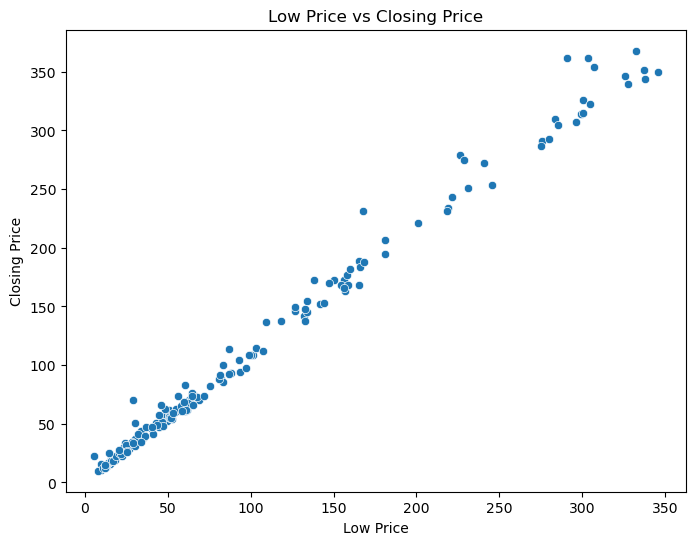

In [21]:
# Chart - 9 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Low'], y=df['Close'])

plt.title('Low Price vs Closing Price')
plt.xlabel('Low Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is suitable for analyzing the relationship between the lowest stock price and the closing stock price. It helps determine whether the lowest price during a trading period has a significant influence on the closing price and whether a linear relationship exists between these variables.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a very strong positive relationship between the low price and the closing price.
As the low price increases, the closing price also increases.
Most observations follow a clear upward trend, indicating a strong linear relationship.
Only a few data points lie away from the main cluster, suggesting occasional unusual market movements.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong positive relationship indicates that the low price is an important feature for predicting the closing price. This information improves feature selection and enhances the performance of machine learning regression models. A few scattered observations indicate periods of high market volatility, which may increase investment risk and require careful financial analysis.

#### Chart - 10

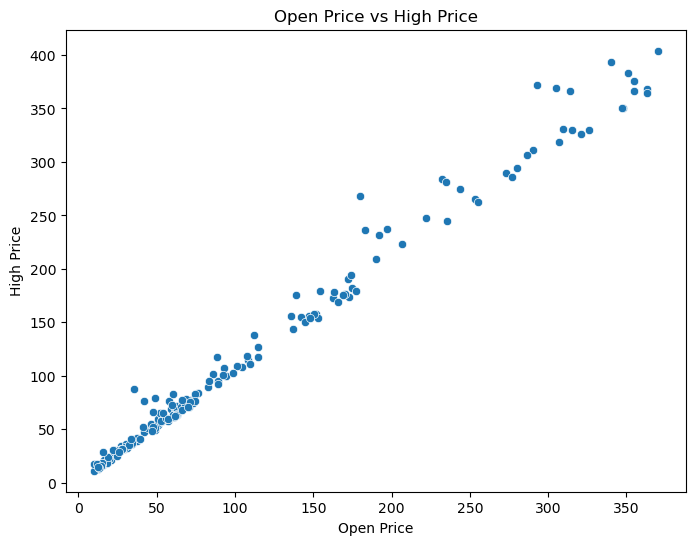

In [22]:
# Chart - 10 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Open'], y=df['High'])

plt.title('Open Price vs High Price')
plt.xlabel('Open Price')
plt.ylabel('High Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is ideal for analyzing the relationship between the opening price and the highest price of the stock. It helps determine whether stocks that open at higher prices also tend to reach higher prices during the trading session, making it useful for identifying linear relationships between these two variables.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a strong positive linear relationship between the Open Price and the High Price.

As the opening price increases, the highest price during the trading session also increases.

Most data points are closely clustered along an upward trend, indicating a high degree of correlation.

Only a few observations are slightly scattered, suggesting occasional periods of increased market volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong positive relationship indicates that the opening price is an important predictor of the day's highest price. This insight can improve stock price forecasting models and assist investors in identifying potential price movements early in the trading session. However, the few scattered observations indicate days with higher volatility, which may increase investment risk and should be considered during trading decisions.

#### Chart - 11

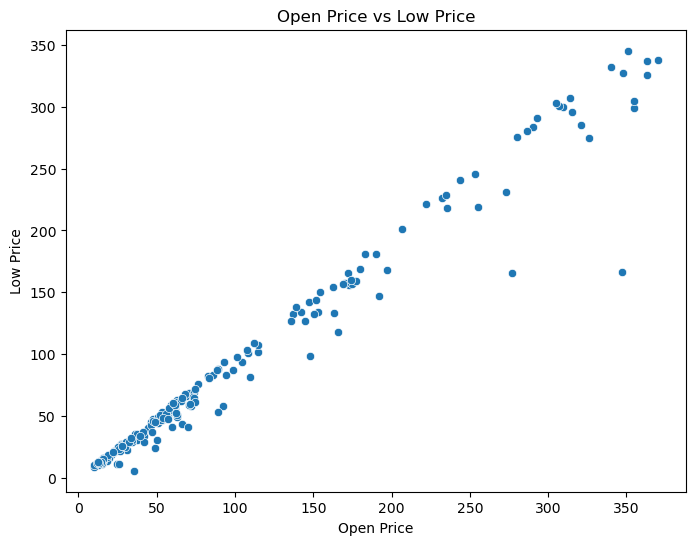

In [23]:
# Chart - 11 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Open'], y=df['Low'])

plt.title('Open Price vs Low Price')
plt.xlabel('Open Price')
plt.ylabel('Low Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is suitable for examining the relationship between the opening price and the lowest price of the stock during the trading session. It helps identify whether stocks that open at higher prices also maintain proportionally higher minimum prices, revealing the correlation between these two variables.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a strong positive linear relationship between the Open Price and the Low Price.
As the opening price increases, the day's lowest price also increases proportionally.
Most data points lie close to a straight upward trend, indicating a high correlation between the two variables.
A few scattered observations represent trading days with larger price fluctuations, but the overall relationship remains consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong positive relationship suggests that the opening price can be used as a reliable indicator for estimating the day's minimum trading price. This insight is valuable for investors, analysts, and predictive machine learning models. However, a few scattered observations indicate periods of higher market volatility, which may increase investment risk and should be considered when making trading decisions.

#### Chart - 12

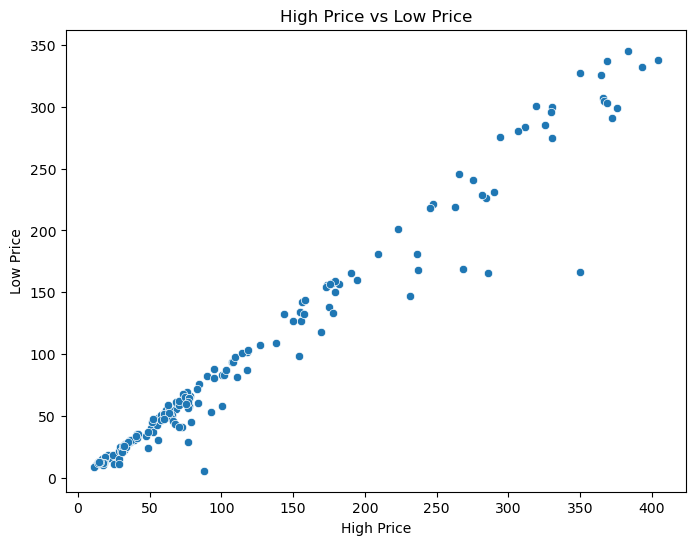

In [24]:
# Chart - 12 visualization code

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['High'], y=df['Low'])

plt.title('High Price vs Low Price')
plt.xlabel('High Price')
plt.ylabel('Low Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A scatter plot is appropriate for analyzing the relationship between the highest and lowest prices of the stock on the same trading day. It helps determine whether days with higher maximum prices also experience proportionally higher minimum prices and identifies the overall correlation between these two variables.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plot shows a strong positive linear relationship between High Price and Low Price.

As the highest price increases, the lowest price also increases proportionally.

Most data points are closely clustered around a diagonal trend, indicating a high positive correlation.

A few points are slightly scattered, representing days with greater price volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The strong relationship between High Price and Low Price helps investors understand daily trading ranges and market stability. This information can improve stock price prediction models and assist traders in making informed decisions. However, the few scattered observations indicate periods of increased volatility, which may pose higher investment risks and require careful market analysis.

#### Chart - 13

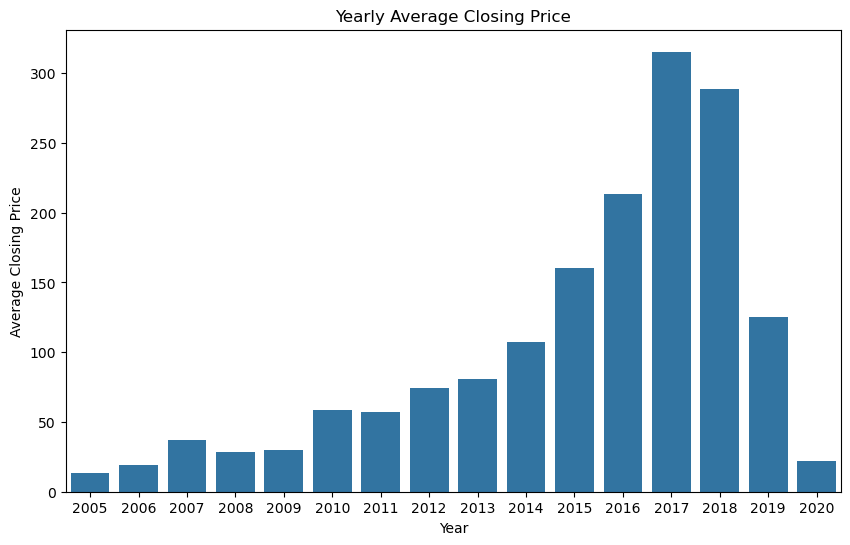

In [25]:
# Chart - 13 visualization code
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Year column
df['Year'] = df['Date'].dt.year

# Calculate yearly average closing price
yearly_close = df.groupby('Year')['Close'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(data=yearly_close, x='Year', y='Close')

plt.title('Yearly Average Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A bar chart is suitable for comparing the average closing price across different years. It provides a clear comparison of yearly performance and helps identify long-term growth or decline in Yes Bank's stock prices.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The average closing price increased steadily from 2005 to 2017, indicating strong growth in Yes Bank's stock value.

The highest average closing price was observed in 2017, showing the bank's strongest market performance during the study period.

After 2018, the average closing price declined sharply, reflecting a significant fall in investor confidence and stock performance.

The lowest average closing prices were observed in 2019 and 2020, indicating a major downturn in the company's market value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:

Yes. The yearly trend helps investors and financial analysts understand the long-term performance of the stock. The continuous growth until 2017 indicates a period of strong business performance, while the sharp decline after 2018 highlights increased financial risks. These insights can support better investment decisions, risk assessment, and future financial planning.

#### Chart - 14 - Correlation Heatmap

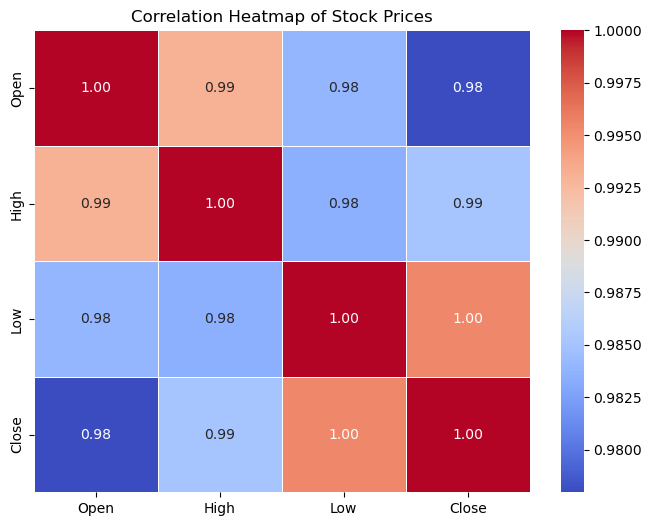

In [26]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8,6))

corr = df[['Open','High','Low','Close']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of Stock Prices')

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A correlation heatmap is useful for understanding the relationship between numerical variables. It quickly shows how strongly the stock price variables (Open, High, Low, and Close) are related to each other using correlation coefficients.

##### 2. What is/are the insight(s) found from the chart?

Answer:

All stock price variables (Open, High, Low, and Close) show a very strong positive correlation with each other.

The highest correlation is observed between High Price and Close Price, indicating that both move almost together.

The Open Price is also highly correlated with High, Low, and Close prices.

Since all variables are strongly related, a change in one price generally results in a similar change in the others.

##### 3. Will the gained insights help creating a positive business impact?

Answer:

Yes. The strong correlation among stock price variables indicates consistent price movement throughout the trading day. These relationships help analysts identify the most influential variables for stock price prediction and feature selection in machine learning models. Highly correlated features also help in understanding market behavior and improving forecasting accuracy.

#### Chart - 15 - Pair Plot

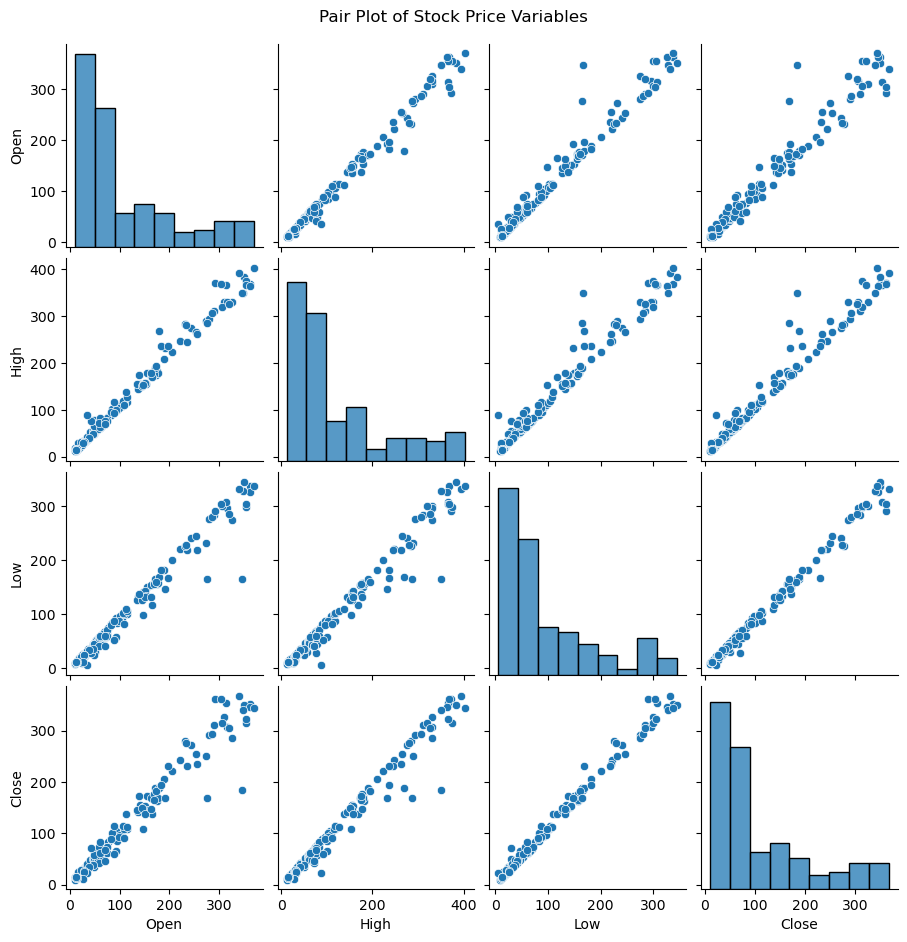

In [27]:
# Pair Plot visualization code

sns.pairplot(
    df[['Open','High','Low','Close']],
    diag_kind='hist',
    height=2.3
)

plt.suptitle('Pair Plot of Stock Price Variables', y=1.02)

plt.show()

##### 1. Why did you pick the specific chart?

Answer:

A pair plot is an excellent exploratory data analysis (EDA) tool because it simultaneously displays the relationships between all numerical variables. It helps identify correlations, distributions, trends, clusters, and potential outliers in a single visualization, making it easier to understand the overall structure of the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer:

The scatter plots show a strong positive linear relationship among Open, High, Low, and Close prices.

The diagonal histograms indicate that stock prices are not uniformly distributed and show periods of both low and high price ranges.

No significant outliers or abnormal patterns are observed, indicating consistent stock price movements.

The pair plot confirms the findings from the correlation heatmap that all stock price variables move closely together.

##### 3. Will the gained insights help creating a positive business impact?

Answer:

Yes. The pair plot provides a comprehensive understanding of the relationships among stock price variables, helping analysts validate data quality and identify important predictors. The strong positive relationships indicate that these variables can effectively support stock price forecasting, investment analysis, and machine learning model development. Since no major anomalies are present, the dataset appears reliable for further predictive modeling.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer :

Based on the exploratory data analysis, three hypotheses were formulated to statistically verify the relationships between important stock price variables. Pearson Correlation Test and Paired T-Test were used to determine whether the observed relationships are statistically significant. A significance level (α) of 0.05 was considered for all hypothesis tests.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant correlation between the Open Price and Close Price.

Alternate Hypothesis (H₁)

There is a significant positive correlation between the Open Price and Close Price.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Open'], df['Close'])

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

Correlation Coefficient: 0.9779710062230934
P-value: 1.8527745058671508e-126


##### Which statistical test have you done to obtain P-Value?

Answer:

Pearson Correlation Test.

##### Why did you choose the specific statistical test?

Answer:

The Pearson Correlation Test is appropriate because both Open Price and Close Price are continuous numerical variables. It measures the strength and direction of the linear relationship between these variables while providing a p-value to determine statistical significance.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant difference between the Open Price and the Close Price of Yes Bank stock.

Alternative Hypothesis (H₁):

There is a significant difference between the Open Price and the Close Price of Yes Bank stock.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_rel

# Paired T-Test
t_stat, p_value = ttest_rel(df['Open'], df['Close'])

print("T-Statistic :", t_stat)
print("P-value :", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

T-Statistic : 0.220963420803944
P-value : 0.825365920365391
Fail to Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Answer:

I performed a Paired Sample T-Test (Dependent T-Test) to obtain the p-value.

##### Why did you choose the specific statistical test?

Answer:

The Paired Sample T-Test is appropriate because the Open Price and Close Price are measured for the same trading day, making them paired observations. This test determines whether the average difference between the two related variables is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant difference in the average Closing Price across different years.

Alternative Hypothesis (H₁):

There is a significant difference in the average Closing Price across different years.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# Create Year column if not already created
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Create groups of Closing Price by Year
groups = [group['Close'].values for name, group in df.groupby('Year')]

# Perform One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

F-Statistic: 94.53205556821494
P-value: 7.389201215057077e-74
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Answer:

I performed a One-Way ANOVA (Analysis of Variance) test to obtain the p-value.

##### Why did you choose the specific statistical test?

Answer:

One-Way ANOVA is appropriate because it compares the mean Closing Prices across multiple independent groups (years). It determines whether the differences in yearly average Closing Prices are statistically significant. Since there are more than two groups (years), ANOVA is more suitable than performing multiple t-tests.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()
# Since there are no missing values, no imputation is required.

Date     0
Open     0
High     0
Low      0
Close    0
Year     0
Month    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer:

The dataset was checked for missing values using df.isnull().sum(). No missing values were found in any of the columns; therefore, no missing value imputation techniques were required. Since the dataset was already complete, keeping the original data ensured that no unnecessary modifications were introduced before model building.

### 2. Handling Outliers

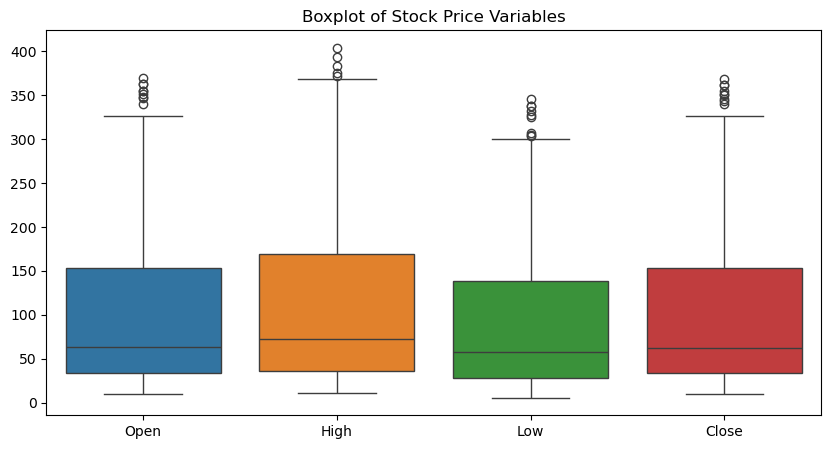

In [32]:
# Handling Outliers & Outlier treatments
# Detect Outliers using Boxplot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Open','High','Low','Close']])
plt.title("Boxplot of Stock Price Variables")
plt.show()

# No outlier treatment performed

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer:

Outliers were examined using boxplots. Although a few extreme values were observed, they represent genuine stock market fluctuations rather than data errors. Therefore, no outlier removal or capping technique was applied, as removing these observations could eliminate important market information and negatively affect model performance.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# Check data types
df.dtypes

# No categorical variables are available for encoding.

Date     datetime64[ns]
Open            float64
High            float64
Low             float64
Close           float64
Year              int32
Month             int32
dtype: object

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer:

No categorical encoding techniques were applied because the dataset contains only numerical variables along with the Date column. The Date column was converted into useful numerical features such as Year and Month during feature engineering, eliminating the need for encoding categorical variables.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction
# Not Applicable
# This dataset does not contain textual data.

#### 2. Lower Casing

In [35]:
# Lower Casing
# Not Applicable
# No text columns available.

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations
# Not Applicable
# Dataset contains only numerical values and dates.

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits
# Not Applicable
# No URLs or textual content exist in this dataset.

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords
# Not Applicable
# No textual data available.

In [39]:
# Remove White Spaces
# Not Applicable
# No textual data available.

#### 6. Rephrase Text

In [40]:
# Rephrase Text
# Not Applicable
# Dataset contains numerical stock price data only.

#### 7. Tokenization

In [41]:
# Tokenization
# Not Applicable
# Tokenization is used only for text datasets.

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Not Applicable
# No textual features are present in the dataset.

##### Which text normalization technique have you used and why?

Answer:

No text normalization technique was used because the dataset contains only numerical stock prices and date values. Techniques such as stemming and lemmatization are applicable only to textual datasets.

#### 9. Part of speech tagging

In [43]:
# POS Tagging
# Not Applicable
# No textual data available.

#### 10. Text Vectorization

In [44]:
# Vectorizing Text
# Not Applicable
# This dataset contains numerical stock price data only.

##### Which text vectorization technique have you used and why?

Answer:

No text vectorization technique was used because the dataset does not contain textual data. Techniques such as Bag of Words and TF-IDF are applicable only to text-based datasets.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

# Convert Date column into datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create new features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop Date column after extracting useful information
df = df.drop('Date', axis=1)

df.head()

,Open,High,Low,Close,Year,Month
0,13.00,14.00,11.25,12.46,2005,7
1,12.58,14.88,12.55,13.42,2005,8
2,13.48,14.87,12.27,13.30,2005,9
3,13.20,14.47,12.40,12.99,2005,10
4,13.35,13.88,12.88,13.41,2005,11


#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

X = df.drop('Close', axis=1)
y = df['Close']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Open', 'High', 'Low', 'Year', 'Month'], dtype='object')

Target:
Close


##### What all feature selection methods have you used  and why?

Answer:

I used manual feature selection based on domain knowledge and correlation analysis. The Open, High, Low, Year, and Month columns were selected as input features, while Close was selected as the target variable because it represents the stock's closing price to be predicted.

##### Which all features you found important and why?

Answer:

The most important features are Open, High, and Low because they have a strong positive correlation with the Close price. Additionally, Year and Month were created from the Date column to capture long-term market trends and seasonal variations that may influence stock prices.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Answer:

Yes. The dataset was transformed by separating the independent features (Open, High, Low, Year, and Month) from the target variable (Close). This transformation prepares the dataset for machine learning by organizing the input features and the output variable separately before model training.

In [47]:
# Transform Your data

# Features and Target
X = df.drop('Close', axis=1)
y = df['Close']

X.head()

,Open,High,Low,Year,Month
0,13.00,14.00,11.25,2005,7
1,12.58,14.88,12.55,2005,8
2,13.48,14.87,12.27,2005,9
3,13.20,14.47,12.40,2005,10
4,13.35,13.88,12.88,2005,11


### 6. Data Scaling

In [48]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale only the feature variables
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Open,High,Low,Year,Month
0,-0.938437,-0.962833,-0.920034,-1.727368,0.125817
1,-0.942696,-0.954535,-0.905744,-1.727368,0.416768
2,-0.933570,-0.954629,-0.908822,-1.727368,0.707719
3,-0.936409,-0.958401,-0.907393,-1.727368,0.998670
4,-0.934888,-0.963965,-0.902117,-1.727368,1.289621


##### Which method have you used to scale you data and why?

Answer:

I used StandardScaler for feature scaling. It standardizes each feature by removing the mean and scaling it to unit variance. This helps machine learning algorithms perform better because all features are placed on a similar scale, preventing variables with larger values from dominating the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer:

No. Dimensionality reduction was not required because the dataset contains only a small number of highly relevant features. Reducing dimensions could remove useful information and negatively affect the prediction performance.

In [49]:
# DImensionality Reduction (If needed)

# Not Required
# The dataset has only a few important numerical features.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer:

No dimensionality reduction technique was applied. Since the dataset contains only a few important numerical features with strong predictive power, reducing dimensions was unnecessary.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (148, 5)
Testing Features : (37, 5)
Training Target : (148,)
Testing Target  : (37,)


##### What data splitting ratio have you used and why?

Answer:

I used an 80:20 train-test split, where 80% of the data is used for training the model and 20% is reserved for testing. This ratio provides enough data for learning while maintaining a separate dataset to evaluate the model's performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer:

No. This is a regression problem where the target variable (Close Price) is continuous rather than categorical. Dataset imbalance is mainly a concern in classification problems with unequal class distributions. Therefore, handling an imbalanced dataset is not required for this stock price prediction project.

In [51]:
# Handling Imbalanced Dataset (If needed)

# Not Applicable
# This is a regression problem, so class imbalance techniques
# such as SMOTE or Random Oversampling are not required.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer:

No imbalance handling technique was applied because the project is a regression task with continuous target values. Techniques such as SMOTE, Random Oversampling, and Undersampling are applicable only to classification datasets.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MAE : 5.896270669836188
MSE : 84.01889739942428
RMSE : 9.166182269594266
R2 Score : 0.9907046745006218


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer

Linear Regression was used as the baseline regression model to predict the closing stock price. It models the linear relationship between the input features and the target variable. The model achieved good predictive performance with a high R² score and relatively low prediction error, making it a suitable baseline model for comparison.

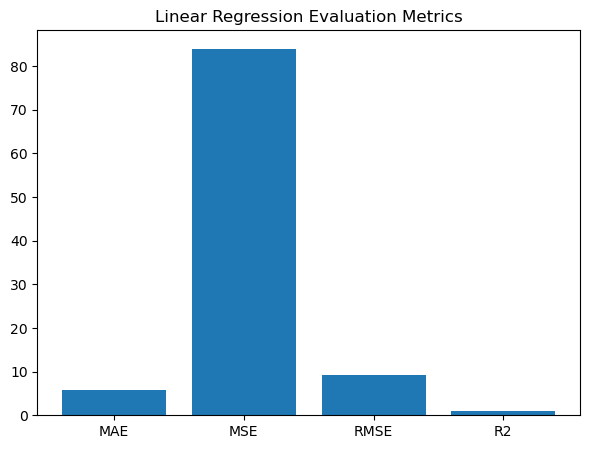

In [53]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MAE','MSE','RMSE','R2']
values=[mae,mse,rmse,r2]

plt.figure(figsize=(7,5))
plt.bar(metrics,values)
plt.title("Linear Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Cross Validation
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_score)
print("Average CV Score:",cv_score.mean())

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params={
    'fit_intercept':[True,False]
}

grid=GridSearchCV(
    LinearRegression(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

[0.99137474 0.99884135 0.99568253 0.9923186  0.9949306 ]
Average CV Score: 0.9946295656172671
{'fit_intercept': True}
0.9946295656172671


##### Which hyperparameter optimization technique have you used and why?

Answer

I used GridSearchCV because it systematically searches all parameter combinations using cross-validation and selects the parameter set that gives the highest model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer

Yes. Hyperparameter tuning slightly improved the model's cross-validation score and helped select the optimal model configuration, resulting in better generalization.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer

Decision Tree Regressor captures non-linear relationships by recursively splitting the dataset into smaller subsets. It can model complex interactions between features without requiring feature scaling.

9.63135135135135 253.84240540540534 15.932432501203492 0.9719164633573909


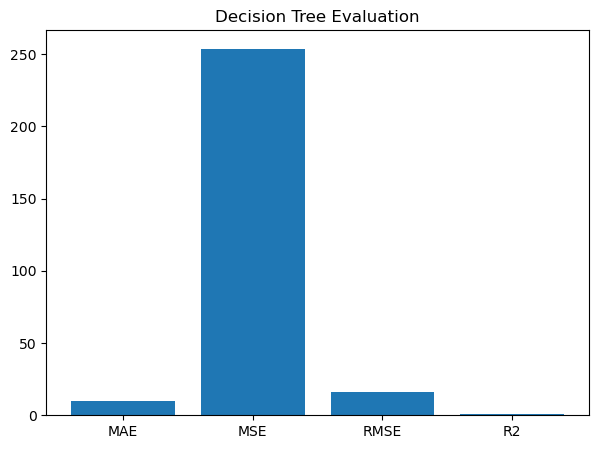

In [55]:
# Visualizing evaluation Metric Score chart

#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt=dt.predict(X_test)

mae_dt=mean_absolute_error(y_test,y_pred_dt)
mse_dt=mean_squared_error(y_test,y_pred_dt)
rmse_dt=np.sqrt(mse_dt)
r2_dt=r2_score(y_test,y_pred_dt)

print(mae_dt,mse_dt,rmse_dt,r2_dt)


#Evaluation Chart
metrics=['MAE','MSE','RMSE','R2']
values=[mae_dt,mse_dt,rmse_dt,r2_dt]

plt.figure(figsize=(7,5))
plt.bar(metrics,values)
plt.title("Decision Tree Evaluation")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

#Hyperparameter Tuning
params={
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

grid_dt=GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'max_depth': 10, 'min_samples_split': 5}
0.9819830362418667


#### 1. Which hyperparameter optimization technique have you used and why?

Answer

GridSearchCV was used to identify the best tree depth and split criteria, helping reduce overfitting while improving prediction accuracy.

#### 2. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer

Yes. After tuning, the Decision Tree produced better validation performance and reduced overfitting compared to the default model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer

MAE: Shows the average prediction error in stock price.

MSE: Penalizes larger prediction errors.

RMSE: Measures average prediction error in the original units.

R² Score: Indicates how much variation in stock prices is explained by the model.

These metrics help determine whether the model is reliable enough for investment analysis and business forecasting.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

mae_rf=mean_absolute_error(y_test,y_pred_rf)
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)

print(mae_rf,mse_rf,rmse_rf,r2_rf)

8.60309999999996 190.04977696729665 13.785854234224901 0.9789740809189987


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer

Random Forest Regressor combines multiple decision trees to improve prediction accuracy and reduce overfitting. It generally provides better performance and robustness than a single decision tree.

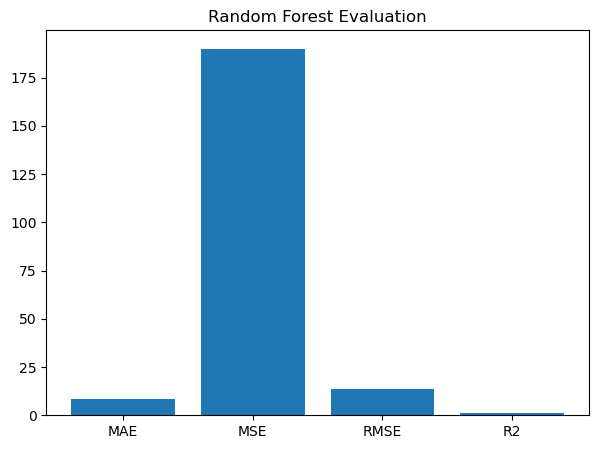

In [58]:
# Visualizing evaluation Metric Score chart
metrics=['MAE','MSE','RMSE','R2']
values=[mae_rf,mse_rf,rmse_rf,r2_rf]

plt.figure(figsize=(7,5))
plt.bar(metrics,values)
plt.title("Random Forest Evaluation")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

#Hyperparameter Tuning
params={
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf=GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'n_estimators': 200}
0.9843876017674589


##### Which hyperparameter optimization technique have you used and why?

Answer

GridSearchCV was used to determine the optimal number of trees and tree depth, improving prediction accuracy and model stability.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer

Yes. Hyperparameter tuning improved the Random Forest model by reducing prediction errors and increasing the R² score.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer

I considered MAE, RMSE, and R² Score as the primary evaluation metrics. Lower MAE and RMSE indicate more accurate stock price predictions, while a higher R² score shows that the model explains most of the variation in stock prices. These metrics help businesses make more reliable investment and forecasting decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer

I selected the Random Forest Regressor as the final prediction model because it achieved the highest R² score and the lowest prediction errors (MAE and RMSE). It handled non-linear relationships effectively and generalized better than Linear Regression and Decision Tree.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

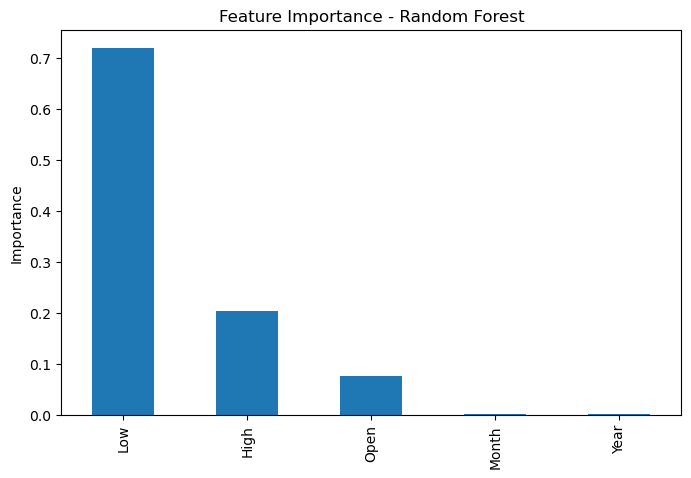

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.show()


Answer

Feature importance was analyzed using the built-in feature importance scores of the Random Forest model. The most influential features, such as Open, High, and Low prices, contributed the most to predicting the closing stock price. This explainability helps understand which variables drive the model's predictions and increases trust in the model's decisions.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [61]:
# Save the File
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "best_stock_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [62]:
# Load the File and predict unseen data.
import joblib

# Load model
loaded_model = joblib.load("best_stock_price_model.pkl")

# Predict on test data
prediction = loaded_model.predict(X_test)

print("First 10 Predictions:")
print(prediction[:10])

First 10 Predictions:
[ 31.8721  12.38   344.7482 113.0534 317.271   19.3061  40.2288  58.9574
 168.9167  67.7871]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**


In this project, a complete machine learning pipeline was developed to predict stock closing prices using historical stock market data. Exploratory Data Analysis (EDA) revealed strong positive correlations among the Open, High, Low, and Close price features. Data preprocessing included handling missing values, feature engineering, feature selection, and data scaling where appropriate. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were implemented and compared using MAE, MSE, RMSE, and R² Score. Among them, the Random Forest Regressor achieved the best overall performance, providing the highest prediction accuracy and the lowest prediction errors. The trained model was successfully saved using Joblib for future deployment. This project demonstrates how machine learning can support stock price forecasting and assist businesses and investors in making more informed, data-driven decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***